## 1. Dataset Overview

## 1.1. Load and merge dataset partitions 

In [1]:
import pandas as pd

# data set is split into 3 partitions, load separately 
df_p1 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P1.json", lines=True)  # JSON lines format
df_p2 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P2.json", lines=True)
df_p3 = pd.read_json("data/raw_static/ARMAS_STATIC_20132023_P3.json", lines=True)

# column called partition with labels 
df_p1["partition"] = "P1"
df_p2["partition"] = "P2"
df_p3["partition"] = "P3"

# merge into one dataset for global exploration
df_all = pd.concat([df_p1, df_p2, df_p3], ignore_index=True)

print(df_all.shape)


(92476, 49)


## 1.2 Initial Dataset Inspection

In [2]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92476 entries, 0 to 92475
Data columns (total 49 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   Datetime               92476 non-null  datetime64[ns, UTC]
 1   ARMAS                  92476 non-null  float64            
 2   NAIRASV3               92476 non-null  float64            
 3   NAIRASV2               92476 non-null  float64            
 4   Latitude               92476 non-null  float64            
 5   Longitude              92476 non-null  float64            
 6   Altitude(Bar)          92476 non-null  float64            
 7   Altitude(GPS)          92476 non-null  float64            
 8   Geomagnetic_latitude   92476 non-null  float64            
 9   Geomagnetic_longitude  92476 non-null  float64            
 10  Geomagnetic_Rc         92476 non-null  float64            
 11  Geomagnetic_Lshell     92476 non-null  float64        

In [3]:
df_all.describe()

,ARMAS,NAIRASV3,NAIRASV2,Latitude,Longitude,Altitude(Bar),Altitude(GPS),Geomagnetic_latitude,Geomagnetic_longitude,Geomagnetic_Rc,...,Index_Dst,Index_Ap,Solar_sunspots,Solar_f107,Solar_NPF,Solar_SPF,Solar_APF,Solar_NPF20,Solar_SPF20,Solar_APF20
count,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,...,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000,92476.000000
mean,9.643342,9.764880,5.967949,13.166842,-82.565163,11055.043295,11499.511650,20.114878,-21.400578,4.050419,...,-11.997859,10.321305,32.188233,86.148469,51.410296,-54.599417,53.092127,46.669535,-61.936573,54.313189
std,5.364425,3.595358,2.516188,42.435218,54.354644,1842.058479,1671.327956,41.355686,44.870526,3.360314,...,17.982176,15.663195,36.656100,22.727240,28.278057,23.878630,15.382372,21.019098,17.870065,14.838726
min,0.046000,1.959000,1.124000,-86.220000,-180.000000,8000.010000,8000.000000,-76.620000,-166.620000,0.000000,...,-126.000000,0.000000,0.000000,65.500000,-21.000000,-103.000000,4.000000,-2.000000,-82.000000,5.000000
25%,4.721000,7.137000,4.362000,5.900000,-112.090000,9543.405000,10241.280000,12.800000,-47.470000,1.610000,...,-20.000000,3.000000,0.000000,69.800000,30.000000,-71.000000,46.000000,29.000000,-72.000000,53.000000
50%,9.271000,9.882000,6.117000,28.400000,-86.035000,10698.010000,11277.600000,36.630000,-15.550000,3.280000,...,-8.000000,5.000000,16.000000,76.300000,52.000000,-47.000000,58.000000,53.000000,-68.000000,61.000000
75%,13.435000,12.000000,7.736000,39.450000,-70.600000,12887.337500,13100.000000,46.970000,0.300000,5.420000,...,0.000000,12.000000,49.000000,97.500000,75.000000,-40.000000,64.000000,64.000000,-56.000000,64.000000
max,42.385000,27.312000,13.850000,82.000000,180.000000,15498.550000,16272.360000,88.420000,166.250000,13.120000,...,34.000000,236.000000,206.000000,220.700000,104.000000,12.857142,71.000000,74.000000,2.000000,65.000000


Notes:
92476 ARMAS measurements (target variable), 48 features (incl. partition)

## 1.3 Feature Overview

In [4]:
df_all.columns.tolist()

['Datetime',
 'ARMAS',
 'NAIRASV3',
 'NAIRASV2',
 'Latitude',
 'Longitude',
 'Altitude(Bar)',
 'Altitude(GPS)',
 'Geomagnetic_latitude',
 'Geomagnetic_longitude',
 'Geomagnetic_Rc',
 'Geomagnetic_Lshell',
 'NM_NEWK',
 'NM_OULU',
 'NM_THUL',
 'NM_SOPO',
 'SXR_short',
 'SXR_long',
 'Particles_P1',
 'Particles_P5',
 'Particles_P10',
 'Particles_P30',
 'Particles_P50',
 'Particles_P100',
 'Particles_E20',
 'SW_B',
 'SW_Bx',
 'SW_By',
 'SW_Bz',
 'SW_V',
 'SW_Vx',
 'SW_Vy',
 'SW_Vz',
 'SW_density',
 'SW_temperature',
 'SW_pressure',
 'Index_Kp',
 'Index_Dst',
 'Index_Ap',
 'Vehicle_ID',
 'Solar_sunspots',
 'Solar_f107',
 'Solar_NPF',
 'Solar_SPF',
 'Solar_APF',
 'Solar_NPF20',
 'Solar_SPF20',
 'Solar_APF20',
 'partition']

Notes:
The dataset has 48 features (inkl. partition feature added for this EDA). 
It includes the target variable ARMAS (radiation measurements), estimations by physics-based models NAIRASV2 and NAIRASV3, geospatial
features, ... 

In [5]:
# checking unique values per feature

for col in df_all.columns:
    print(f"{col}: {df_all[col].nunique()} unique values")

Datetime: 92468 unique values
ARMAS: 9009 unique values
NAIRASV3: 15803 unique values
NAIRASV2: 5675 unique values
Latitude: 10613 unique values
Longitude: 14819 unique values
Altitude(Bar): 70265 unique values
Altitude(GPS): 12867 unique values
Geomagnetic_latitude: 11862 unique values
Geomagnetic_longitude: 17546 unique values
Geomagnetic_Rc: 1285 unique values
Geomagnetic_Lshell: 2201 unique values
NM_NEWK: 5472 unique values
NM_OULU: 9694 unique values
NM_THUL: 7700 unique values
NM_SOPO: 12241 unique values
SXR_short: 89195 unique values
SXR_long: 87786 unique values
Particles_P1: 5183 unique values
Particles_P5: 3284 unique values
Particles_P10: 3223 unique values
Particles_P30: 3083 unique values
Particles_P50: 2989 unique values
Particles_P100: 3039 unique values
Particles_E20: 5608 unique values
SW_B: 2142 unique values
SW_Bx: 2460 unique values
SW_By: 2596 unique values
SW_Bz: 2491 unique values
SW_V: 5098 unique values
SW_Vx: 5108 unique values
SW_Vy: 2527 unique values
SW_V

Notes:
Only 36 unique values for Vehicle_ID, meaning vehicles flew multiple flights. There is no feature defining separate flights, meaning this would have to be reconstructed by e.g. filtering for time breaks, if single flights become a necessary item. 

## 1.4 Data Quality Check

In [6]:
missing = df_all.isna().sum()

missing[missing > 0]

Series([], dtype: int64)

In [7]:
df_all.duplicated().sum()

np.int64(0)

In [8]:
# change date to timestamp for single flight reconstruction later

df_all["Datetime"] = pd.to_datetime(df_all["Datetime"])
df_all["Datetime"].dtype

datetime64[ns, UTC]

In [9]:
(df_all["ARMAS"] < 0).sum()

np.int64(0)

Notes:
No missing values, no dupicate rows, no negative radiation values were detected. As the dataset was explicitely released as a ML-ready dataset, the data quality check was kept to a minimum.

## 1.5 Target Analysis

In [10]:
df_all["ARMAS"].describe()

count    92476.000000
mean         9.643342
std          5.364425
min          0.046000
25%          4.721000
50%          9.271000
75%         13.435000
max         42.385000
Name: ARMAS, dtype: float64

Notes:
The ARMAS measurements range from near 0 to a max value of 42.4 µSv/h.
The distribution shows positive/right skew, with the mean slightly exceeding the median (50%). 
75% of values are smaller than 15 µSv/h, while higher measurements occur much less. This points to a long-tailed distribution and data imbalance.

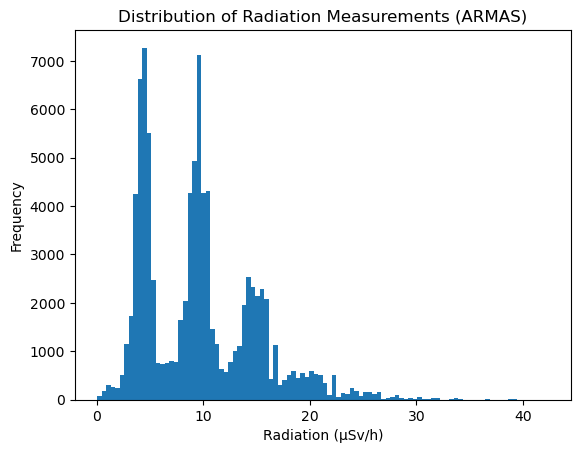

In [11]:
# distribution visualization

import matplotlib.pyplot as plt

plt.hist(df_all["ARMAS"], bins=100)
plt.xlabel("Radiation (µSv/h)")
plt.ylabel("Frequency")
plt.title("Distribution of Radiation Measurements (ARMAS)")

# save figure
plt.savefig("armas_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

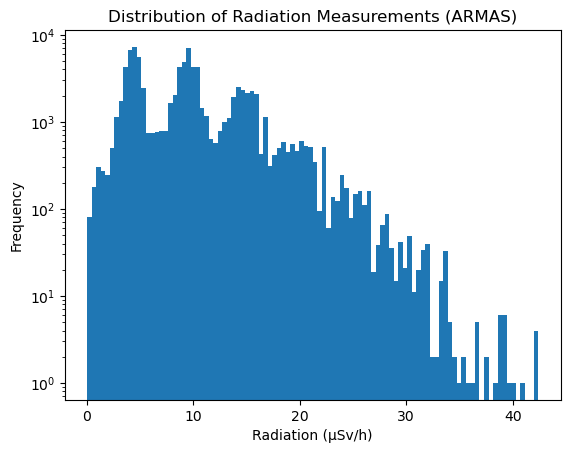

In [12]:
# distribution visualization with log scale to visualize rare measurements better

import matplotlib.pyplot as plt

plt.hist(df_all["ARMAS"], bins=100)
plt.xlabel("Radiation (µSv/h)")
plt.ylabel("Frequency")
plt.title("Distribution of Radiation Measurements (ARMAS)")
plt.yscale("log")
plt.show()

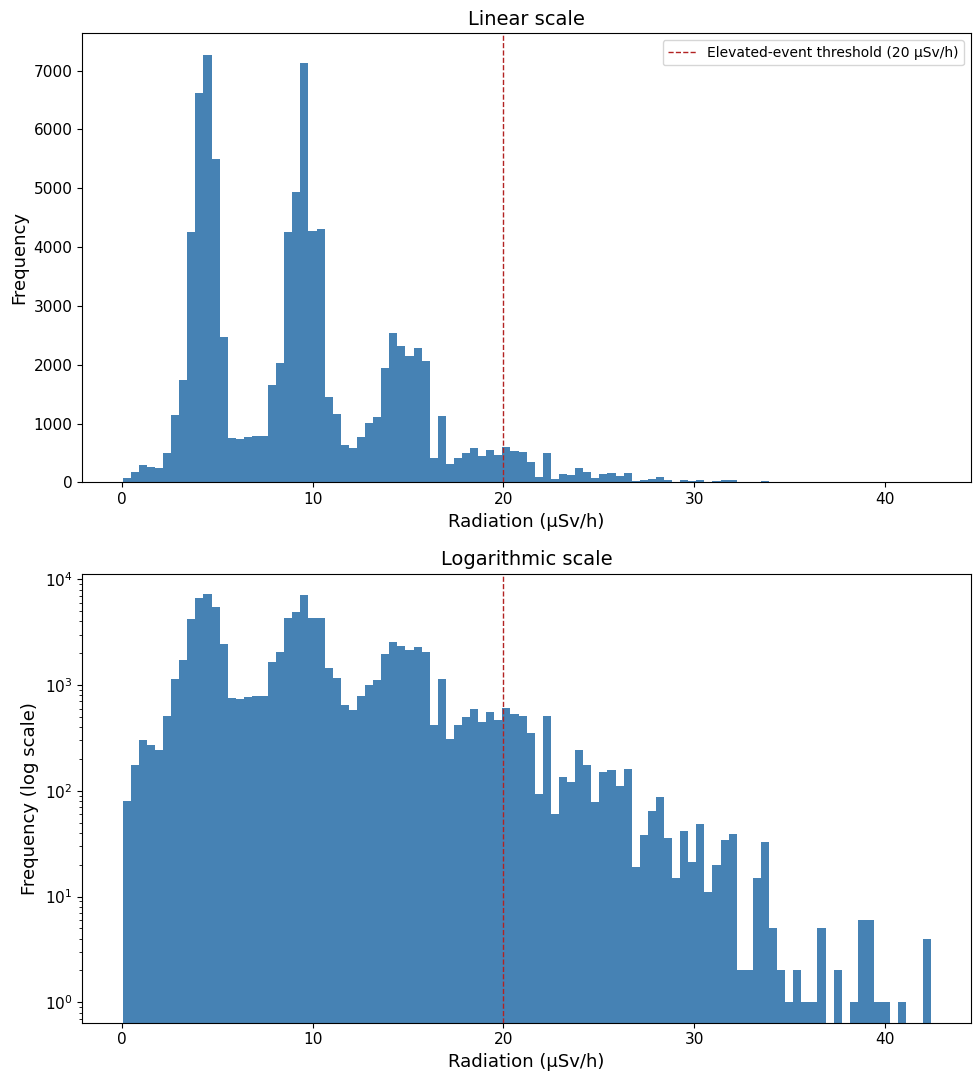

In [13]:
# 2 panel histogram for thesis

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

fig, axes = plt.subplots(2, 1, figsize=(10, 11))

# Oben: lineare Skala — zeigt Skew und multimodale Struktur
axes[0].hist(df_all["ARMAS"], bins=100, color="steelblue")
axes[0].axvline(20, color="firebrick", linestyle="--", linewidth=1,
                label="Elevated-event threshold (20 µSv/h)")
axes[0].set_xlabel("Radiation (µSv/h)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Linear scale")
axes[0].legend()

# Unten: logarithmische Skala — zeigt den langen, populierten Tail
axes[1].hist(df_all["ARMAS"], bins=100, color="steelblue")
axes[1].set_yscale("log")
axes[1].axvline(20, color="firebrick", linestyle="--", linewidth=1)
axes[1].set_xlabel("Radiation (µSv/h)")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_title("Logarithmic scale")

fig.tight_layout()
fig.savefig("fig_armas_distribution.pdf", bbox_inches="tight")
plt.show()

In [14]:
# How many measurements of extreme events over ≥20 µSv/h radiation

threshold = 20
n_extreme = (df_all["ARMAS"] >= threshold).sum()
print(f"Elevated Events (≥20 µSv/h): {n_extreme} ({n_extreme/len(df_all)*100:.2f}%)")

Extreme Events (≥20 µSv/h): 4439 (4.80%)


In [15]:
radiation_bins = pd.cut(
    df_all["ARMAS"],
    bins=[0, 5, 10, 15, 20, 30, 50],
    labels=["0-5", "5-10", "10-15", "15-20", "20-30", "30-50"]
)

bin_counts = radiation_bins.value_counts().sort_index()

bin_percentages = (
    radiation_bins
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

radiation_summary = pd.DataFrame({
    "Count": bin_counts,
    "Percentage": bin_percentages.round(2)
})

radiation_summary

,Count,Percentage
ARMAS,,
0-5,27139,29.35
5-10,29312,31.70
10-15,20752,22.44
15-20,10834,11.72
20-30,4193,4.53
30-50,246,0.27


In [16]:
# Percentiles: Exploring how many percent of the data are below a certain value

armas_percentiles = df_all["ARMAS"].quantile([
    0.50,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

armas_percentiles

0.500     9.271
0.900    16.335
0.950    19.849
0.990    25.651
0.995    27.711
0.999    32.148
Name: ARMAS, dtype: float64

Notes:
Target variable exhibits a highly skewed long-tailed distribution, with 4.8% of observations exceeding 20 µSv/h. 
Most of the data (31.7%) falls between 5-10 µSv/h, followed by 0-5 µSv/h (29.3%).
The percentile analysis shows that 95% of the data are below 19.8 µSv/h, which means 95% of the data fall below the threshold for extreme radiation events (20 µSv/h). 50% of the data shows measurements of below 10 µSv/h. Radiation levels of above 30 µSv/h are very rare and correspond to only 0.1% of the data.
The explored data imbalance might provide struggles for machine learning models. 

## 1.6 Flight Reconstruction / Temporal Structure

Information: This subsection was explored as part of an initial investigation into temporal sequence modelling. However, due to uncleared quality issues within the temporal dataset version, the final thesis focuses on the static ML-ready dataset representation and therefore does not use reconstructed flight sequences for model training.

In [17]:
# measurements per vehicle ID

df_all.groupby("Vehicle_ID").size().describe()

count       36.000000
mean      2568.777778
std       4469.324967
min          7.000000
25%         81.500000
50%        448.500000
75%       3149.750000
max      20004.000000
dtype: float64

In [18]:
df_all.groupby("Vehicle_ID").size().sort_values(ascending=False)

Vehicle_ID
G-IV**        20004
DC87          14740
DC-8**         9463
Unknwn         8685
G-V*           7213
G-V***         5801
Unkn           4254
(AFRC          3878
B772           3275
AFRC           3108
B739           2491
GLF4           1601
B789           1160
B738           1149
B39M           1026
PN-2           1023
B752            867
data            529
B753            368
B78X            364
A320            284
commercial      235
E75L            172
A21N            139
CRJ2            107
A20N            101
A319             82
B788             80
C200             72
E145             67
E175             37
B737             33
NSLbln           22
E170             20
WV-bln           19
CRJ9              7
dtype: int64

Notes:
The dataset contains measurements from 36 unique aircraft (Vehicle_ID) with an average of 2569 measurements per aircraft. 
Measurements per aircraft are distributed highly unevenly, with 50% containing fewer than 449 measurements, while the max value contains 20004 measurements.
The dataset contains 36 unique Vehicle_IDs, while the original dataset documentation states the dataset contains 589 flights. Since there is no single feature identifying flights, flights must be reconstructed via discontinuities in the Datetime feature for each Vehicle_ID. 

In [19]:

# sort by time
df_all = df_all.sort_values("Datetime").copy()

# calculate time gaps
df_all["time_gap"] = df_all["Datetime"].diff()

In [20]:
# trying different thresholds to find time gap between flights

thresholds = [2, 5, 10, 15, 30, 60] # minutes

for t in thresholds:

    threshold = pd.Timedelta(minutes=t)

    flight_ids = (
        df_all["time_gap"] > threshold
    ).cumsum()

    n_flights = flight_ids.nunique()

    median_len = (
        df_all.groupby(flight_ids)
        .size()
        .median()
    )

    print(
        f"{t:>2} min threshold means "
        f"{n_flights:>4} flights, "
        f"median length = {median_len}"
    )

 2 min threshold means 2017 flights, median length = 17.0
 5 min threshold means 1278 flights, median length = 34.0
10 min threshold means  979 flights, median length = 49.0
15 min threshold means  829 flights, median length = 62.0
30 min threshold means  746 flights, median length = 69.0
60 min threshold means  630 flights, median length = 96.0


Notes:
Since the ARMAS measurements take place approx. every minute, time gaps larger than 1 minute could indicate the start of a new flight. 
Due to preprocessing for the dataset by the dataset providers (e.g. removing certain altitude ranges) larger gaps may also appear in the same flight.
Therefore, time gap thresholds starting from 2 minutes up to 60 minutes were tested. A 60 minute time gap would indicate approx. 630 flights, which is a good approximation to the number of flights mentioned in the dataset description (589). 

In [21]:
thresholds = range(30, 181, 5)

results = []

for t in thresholds:

    n_flights = (
        (df_all["time_gap"] > pd.Timedelta(minutes=t))
        .cumsum()
        .nunique()
    )

    results.append({
        "threshold_min": t,
        "n_flights": n_flights,
        "difference": abs(n_flights - 589)
    })

results_df = pd.DataFrame(results)

print(
    results_df.sort_values("difference").head(10)
)

    threshold_min  n_flights  difference
18            120        589           0
17            115        589           0
19            125        586           3
16            110        594           5
20            130        583           6
15            105        597           8
14            100        598           9
21            135        579          10
13             95        602          13
22            140        575          14


Notes:
A time-gap threshold between 115 and 120 minutes reproduced the 589 flights reported in the dataset description.

In [22]:
threshold = pd.Timedelta(minutes=120)

df_all = df_all.sort_values("Datetime").copy()

df_all["time_gap"] = df_all["Datetime"].diff()

df_all["flight_id"] = (
    df_all["time_gap"] > threshold
).cumsum()

In [23]:
flight_summary = (
    df_all.groupby("flight_id")
    .agg(
        start=("Datetime", "min"),
        end=("Datetime", "max"),
        n_measurements=("flight_id", "size")
    )
)

flight_summary["duration"] = (
    flight_summary["end"] - flight_summary["start"]
)

print(flight_summary.head())

print("\nNumber of flights:")
print(len(flight_summary))

print("\nFlight duration statistics:")
print(flight_summary["duration"].describe())

                              start                       end  n_measurements  \
flight_id                                                                       
0         2013-06-28 03:00:18+00:00 2013-06-28 05:37:35+00:00              84   
1         2013-08-03 00:47:44+00:00 2013-08-03 01:56:21+00:00              58   
2         2013-08-05 21:54:20+00:00 2013-08-05 22:42:14+00:00              49   
3         2013-08-06 18:41:37+00:00 2013-08-06 18:46:36+00:00               6   
4         2013-08-08 17:04:30+00:00 2013-08-08 21:15:30+00:00             194   

                 duration  
flight_id                  
0         0 days 02:37:17  
1         0 days 01:08:37  
2         0 days 00:47:54  
3         0 days 00:04:59  
4         0 days 04:11:00  

Number of flights:
589

Flight duration statistics:
count                          589
mean     0 days 03:01:55.049235993
std      0 days 02:37:59.015829426
min                0 days 00:00:00
25%                0 days 00:54:24
50%     

In [24]:
# sort by flight duration

print(
    flight_summary
    .sort_values("duration", ascending=False)
    .head(10)
)

                              start                       end  n_measurements  \
flight_id                                                                       
92        2016-04-16 18:16:10+00:00 2016-04-17 07:17:10+00:00             756   
209       2017-06-10 18:43:33+00:00 2017-06-11 07:05:14+00:00             693   
187       2017-02-18 09:44:35+00:00 2017-02-18 22:01:15+00:00             487   
94        2016-04-25 07:03:07+00:00 2016-04-25 18:38:10+00:00             558   
40        2014-09-03 06:37:30+00:00 2014-09-03 17:04:42+00:00             411   
96        2016-04-30 19:23:10+00:00 2016-05-01 05:43:10+00:00             601   
46        2015-09-18 14:12:00+00:00 2015-09-19 00:14:00+00:00             424   
168       2016-11-12 20:48:10+00:00 2016-11-13 06:50:10+00:00             539   
57        2015-10-12 12:20:50+00:00 2015-10-12 22:20:50+00:00             601   
561       2022-07-25 07:47:10+00:00 2022-07-25 17:46:10+00:00             576   

                 duration  

Notes:
The flight durations seem realistic, with a mean of 3h 2 min, a median of 2h 27 min. and a max value of 13h 1 min. 

In [25]:
for partition_name, group in df_all.groupby("partition"):

    duration = (
        group["Datetime"].max()
        - group["Datetime"].min()
    )

    print(
        partition_name,
        len(group),
        duration
    )

P1 32380 3555 days 20:53:58
P2 30787 3521 days 23:06:26
P3 29309 3550 days 20:45:04


In [26]:
flight_partition_check = (
    df_all.groupby("flight_id")["partition"]
    .nunique()
)

print(
    flight_partition_check.value_counts()
)

partition
1    556
2     28
3      5
Name: count, dtype: int64


Notes:
556 out of 589 of our reconstructed flights only contain data from one partition instead of multiple partitions. 

In [27]:
# how are the reconstructed flights distributed across the 3 dataset partitions

df_all.groupby("partition")["flight_id"].nunique()

partition
P1    210
P2    209
P3    208
Name: flight_id, dtype: int64

In [28]:
# how many measurements belong to each flight in the 3 partitions

partition_flight_sizes = (
    df_all.groupby(["partition", "flight_id"])
    .size()
)

print(
    partition_flight_sizes.groupby("partition")
    .describe()
)

           count        mean         std  min    25%    50%    75%    max
partition                                                                
P1         210.0  154.190476  143.883033  5.0  49.25  102.5  219.0  756.0
P2         209.0  147.306220  130.220235  1.0  48.00   92.0  216.0  590.0
P3         208.0  140.908654  132.761987  1.0  45.50   92.0  197.5  696.0


Notes:
The reconstructed flights are distributed evenly across the 3 partitions. 

In [29]:
# keep flight_id feature

df_all["flight_id"]

0          0
1          0
2          0
3          0
4          0
        ... 
63162    588
63163    588
63164    588
63165    588
63166    588
Name: flight_id, Length: 92476, dtype: int64

## 1.7 Feature Relationships

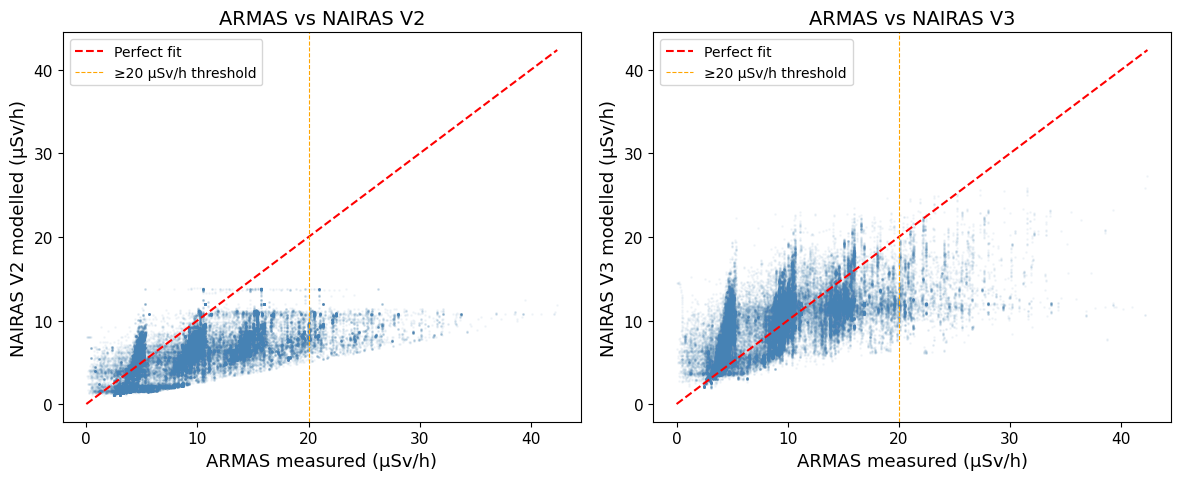

In [30]:
#  plot ARMAS (target) vs NAIRAS V2 and V3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ["NAIRASV2", "NAIRASV3"], ["NAIRAS V2", "NAIRAS V3"]):
    ax.scatter(df_all["ARMAS"], df_all[col], alpha=0.05, s=1, color="steelblue")
    max_val = max(df_all["ARMAS"].max(), df_all[col].max())
    ax.plot([0, max_val], [0, max_val], "r--", label="Perfect fit")
    ax.axvline(20, color="orange", linestyle="--", linewidth=0.8, label="≥20 µSv/h threshold")
    ax.set_xlabel("ARMAS measured (µSv/h)")
    ax.set_ylabel(f"{title} modelled (µSv/h)")
    ax.set_title(f"ARMAS vs {title}")
    ax.legend()

plt.tight_layout()
plt.show()

Notes:
It's clearly visible that NAIRAS V3 performs better on higher values than V2.
However, both models underestimate radiation exposure above 20 µSv/h.
This is a problem since 20 µSv/h marks the threshold for "elevated events" and therefore correct estimations are safety-critical.

In [31]:
# metrics-based comparison NAIRAS V2 and V3

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

for col in ["NAIRASV2", "NAIRASV3"]:

    mae = mean_absolute_error(
        df_all["ARMAS"],
        df_all[col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            df_all["ARMAS"],
            df_all[col]
        )
    )

    corr = df_all["ARMAS"].corr(df_all[col])

    print(f"\n{col}")
    print(f"Correlation: {corr:.3f}")
    print(f"MAE:         {mae:.3f}")
    print(f"RMSE:        {rmse:.3f}")


NAIRASV2
Correlation: 0.656
MAE:         4.199
RMSE:        5.558

NAIRASV3
Correlation: 0.657
MAE:         3.022
RMSE:        4.047


Notes:
The correlation of both NAIRAS models to ARMAS is almost identical. 
However, MAE and RMSE are much smaller for V3 than for V2, which indicates that V3 performs more accurate radiation predictions overall. 

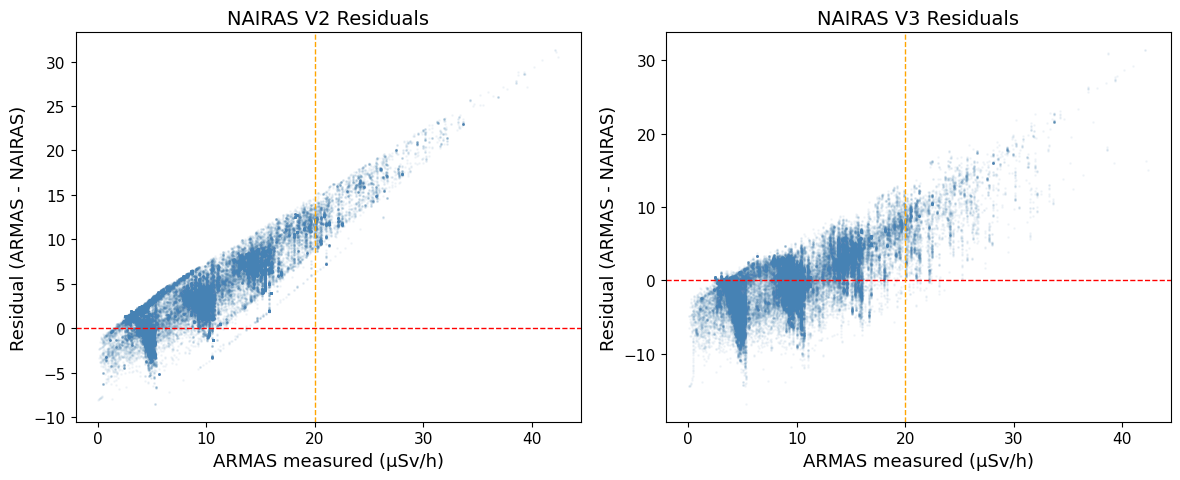

In [32]:
# Residuals
df_all["residual_v2"] = (
    df_all["ARMAS"] - df_all["NAIRASV2"]
)

df_all["residual_v3"] = (
    df_all["ARMAS"] - df_all["NAIRASV3"]
)

# Plot residuals vs measured ARMAS radiation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, residual_col, title in zip(
    axes,
    ["residual_v2", "residual_v3"],
    ["NAIRAS V2 Residuals", "NAIRAS V3 Residuals"]
):

    ax.scatter(
        df_all["ARMAS"],
        df_all[residual_col],
        alpha=0.05,
        s=1,
        color="steelblue"
    )

    # zero-error reference
    ax.axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=1
    )

    # extreme event threshold
    ax.axvline(
        20,
        color="orange",
        linestyle="--",
        linewidth=1
    )

    ax.set_xlabel("ARMAS measured (µSv/h)")
    ax.set_ylabel("Residual (ARMAS - NAIRAS)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

Notes:
Residual analysis reveals a systematic underestimation of radiation exposure by both NAIRAS versions at higher ARMAS values.
This effect is substantially stronger for NAIRAS V2, whose residuals increase almost linearly with increasing measured radiation levels.
Although NAIRAS V3 reduces the magnitude and spread of residuals, both models continue to underestimate extreme radiation events above 20 µSv/h.

In [33]:
# feature correlation (numbers)

corr = df_all.select_dtypes(include=["number"]).corr()["ARMAS"].sort_values(ascending=False)
print(corr.head(15))
print(corr.tail(10))

ARMAS                    1.000000
residual_v2              0.890383
residual_v3              0.742255
NAIRASV3                 0.656906
NAIRASV2                 0.656465
Geomagnetic_longitude    0.241404
Longitude                0.175431
Altitude(GPS)            0.127554
Altitude(Bar)            0.081616
SW_V                     0.074219
Particles_P100           0.073397
Geomagnetic_Lshell       0.055952
Particles_P50            0.053900
Solar_f107               0.042339
Solar_SPF                0.039232
Name: ARMAS, dtype: float64
Geomagnetic_latitude   -0.076141
NM_THUL                -0.077899
Solar_APF              -0.077945
Latitude               -0.086169
SW_Vz                  -0.091404
SW_density             -0.092906
NM_OULU                -0.117698
NM_SOPO                -0.128447
NM_NEWK                -0.132967
Geomagnetic_Rc         -0.499621
Name: ARMAS, dtype: float64


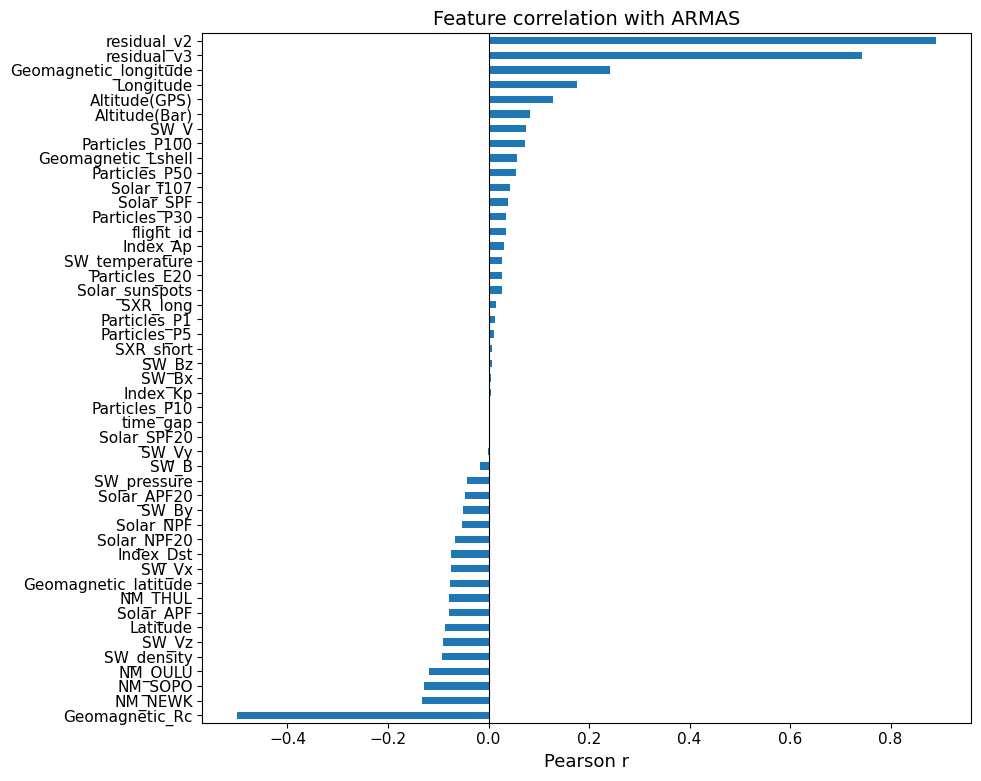

In [34]:
# correlation plot 

import seaborn as sns

# only selected cols and numericals
features = [col for col in df_all.select_dtypes(include="number").columns 
            if col not in ["ARMAS", "NAIRASV2", "NAIRASV3"]]

corr = df_all[features + ["ARMAS"]].corr()["ARMAS"].sort_values()

plt.figure(figsize=(10, 8))
corr.drop("ARMAS").plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature correlation with ARMAS")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

Notes:
Pearson r measures linear correlation between ARMAS measurements and features (-1 to +1), however: can only recognise linear correlation.
For XGBoost / MLP Shap would be better. 

Above: Positive correlation (if feature value rises, ARMAS rises) 
Geomagnetic: strongest single predictor 
Longitude: very strong, however might be geographical bias (97% of data America-centric)
Altitude: Makes sense, the higher, the more radiation.
SW_V (solar wind speed) + particles_p100: moderate effect

Below: Negative correlation (if feature value rises, ARMAS lowers)
Geomagnetic: strongest single predictor
NM features: high NM values indicate calm sun phases

Important:
Radiation doesn't behave in a linear way. E.g. the correlation between altitude and radiation is more exponential than linear. 

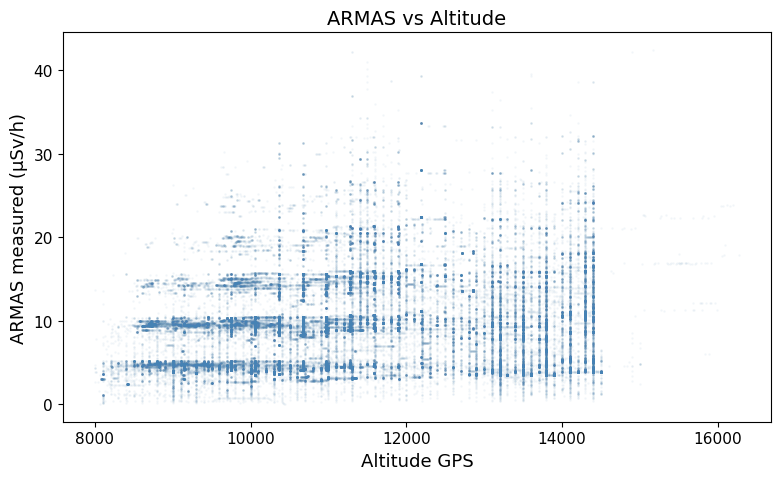

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

alt_col = "Altitude(GPS)"

# Scatterplot: ARMAS vs altitude
plt.figure(figsize=(8, 5))
plt.scatter(
    df_all[alt_col],
    df_all["ARMAS"],
    alpha=0.04,
    s=1,
    color="steelblue"
)

plt.xlabel("Altitude GPS")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("ARMAS vs Altitude")
plt.tight_layout()
plt.show()

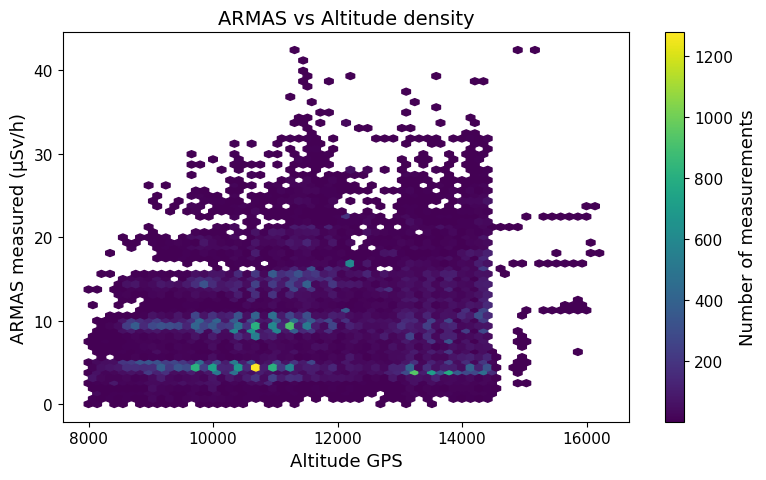

In [36]:
# 2. Hexbin plot: better for many points
plt.figure(figsize=(8, 5))

hb = plt.hexbin(
    df_all[alt_col],
    df_all["ARMAS"],
    gridsize=60,
    mincnt=1
)

plt.colorbar(hb, label="Number of measurements")
plt.xlabel("Altitude GPS")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("ARMAS vs Altitude density")
plt.tight_layout()
plt.show()

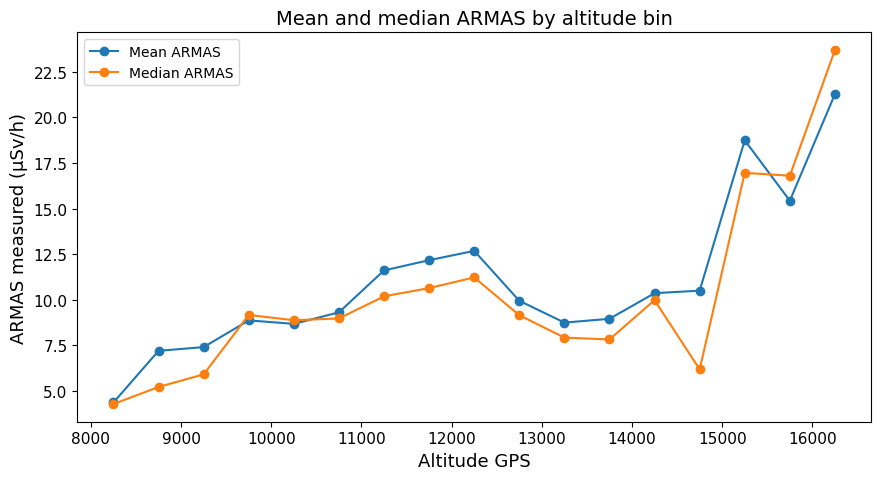

In [37]:
# 3. Mean ARMAS by altitude bins
df_all["altitude_bin"] = pd.cut(
    df_all[alt_col],
    bins=np.arange(
        df_all[alt_col].min(),
        df_all[alt_col].max() + 500,
        500
    )
)

altitude_summary = (
    df_all.groupby("altitude_bin", observed=True)
    .agg(
        mean_ARMAS=("ARMAS", "mean"),
        median_ARMAS=("ARMAS", "median"),
        count=("ARMAS", "size")
    )
    .reset_index()
)

altitude_summary["altitude_mid"] = altitude_summary["altitude_bin"].apply(
    lambda x: x.mid
)

plt.figure(figsize=(9, 5))

plt.plot(
    altitude_summary["altitude_mid"],
    altitude_summary["mean_ARMAS"],
    marker="o",
    label="Mean ARMAS"
)

plt.plot(
    altitude_summary["altitude_mid"],
    altitude_summary["median_ARMAS"],
    marker="o",
    label="Median ARMAS"
)

plt.xlabel("Altitude GPS")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("Mean and median ARMAS by altitude bin")
plt.legend()
plt.tight_layout()
plt.show()

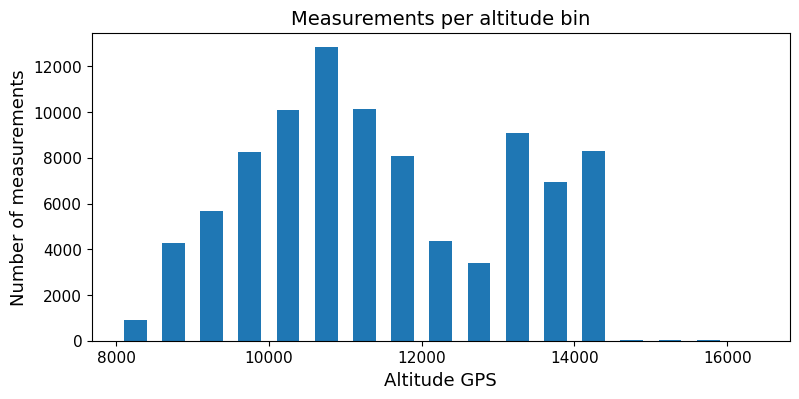

In [38]:
plt.figure(figsize=(9,4))

plt.bar(
    altitude_summary["altitude_mid"],
    altitude_summary["count"],
    width=300
)

plt.xlabel("Altitude GPS")
plt.ylabel("Number of measurements")
plt.title("Measurements per altitude bin")

plt.show()

Notes:
Radiation exposure generally increases with altitude, however the relationship is non-linear and exhibits increasing variability 
at higher altitudes.
The highest concentration of measurements is observed in approximately 9 - 14 km altitude, which are typical commercial flight altitudes.
Mean and median ARMAS values increase overall with altitude. However, fluctuations at extreme altitudes above ca. 14.5 km are likely influenced by limited sample sizes.

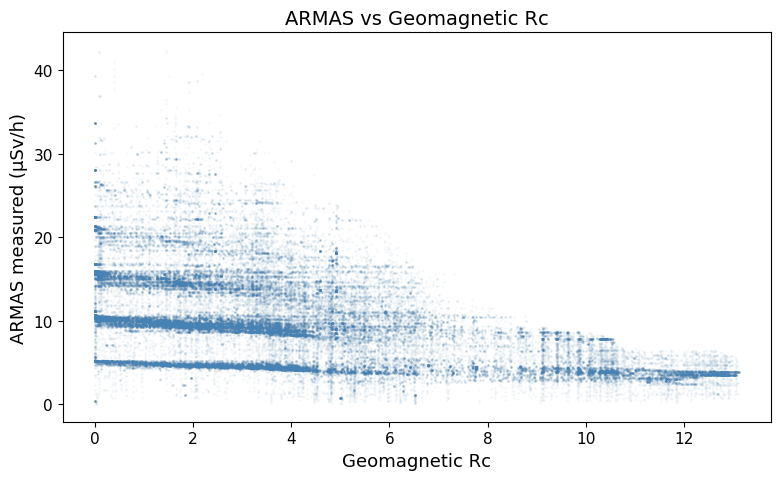

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

geo_rc = "Geomagnetic_Rc"

# 1. Scatterplot: ARMAS vs geomagnetic cutoff rigidity
plt.figure(figsize=(8, 5))
plt.scatter(
    df_all[geo_rc],
    df_all["ARMAS"],
    alpha=0.04,
    s=1,
    color="steelblue"
)

plt.xlabel("Geomagnetic Rc")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("ARMAS vs Geomagnetic Rc")
plt.tight_layout()
plt.show()

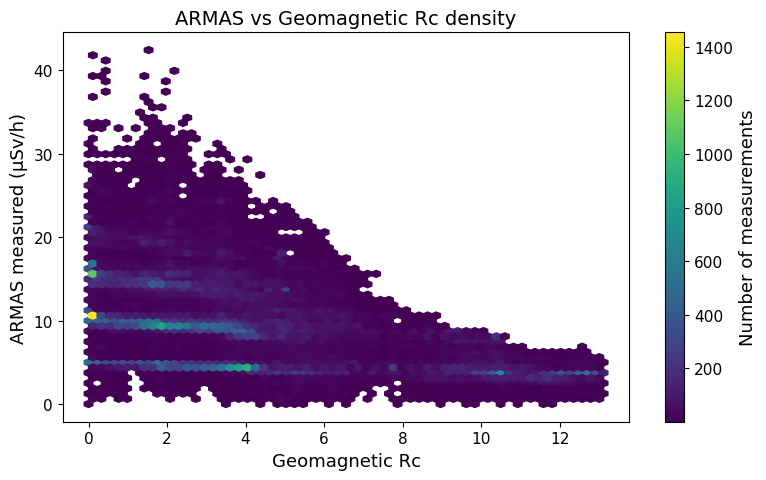

In [40]:
# 2. Hexbin plot
plt.figure(figsize=(8, 5))

hb = plt.hexbin(
    df_all[geo_rc],
    df_all["ARMAS"],
    gridsize=60,
    mincnt=1
)

plt.colorbar(hb, label="Number of measurements")
plt.xlabel("Geomagnetic Rc")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("ARMAS vs Geomagnetic Rc density")
plt.tight_layout()
plt.show()

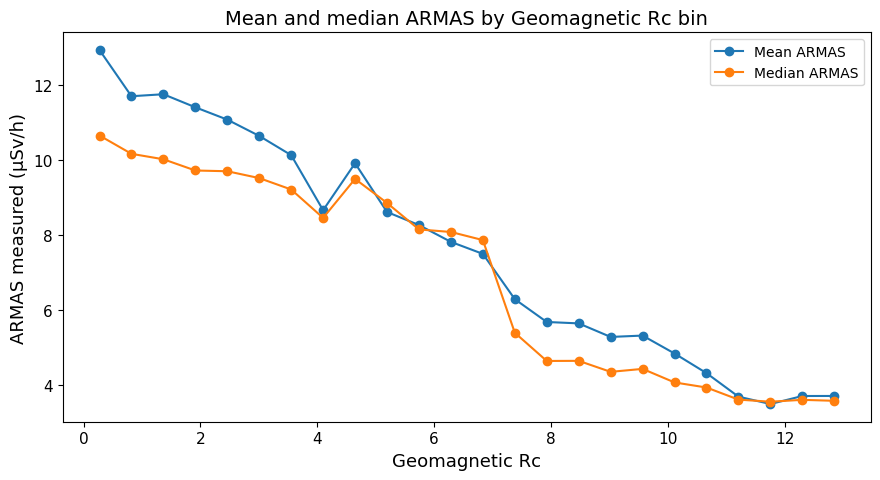

In [41]:
# 3. Mean/median ARMAS by Geomagnetic Rc bins
df_all["rc_bin"] = pd.cut(
    df_all[geo_rc],
    bins=np.linspace(
        df_all[geo_rc].min(),
        df_all[geo_rc].max(),
        25
    )
)

rc_summary = (
    df_all.groupby("rc_bin", observed=True)
    .agg(
        mean_ARMAS=("ARMAS", "mean"),
        median_ARMAS=("ARMAS", "median"),
        count=("ARMAS", "size")
    )
    .reset_index()
)

rc_summary["rc_mid"] = rc_summary["rc_bin"].apply(
    lambda x: x.mid
)

plt.figure(figsize=(9, 5))

plt.plot(
    rc_summary["rc_mid"],
    rc_summary["mean_ARMAS"],
    marker="o",
    label="Mean ARMAS"
)

plt.plot(
    rc_summary["rc_mid"],
    rc_summary["median_ARMAS"],
    marker="o",
    label="Median ARMAS"
)

plt.xlabel("Geomagnetic Rc")
plt.ylabel("ARMAS measured (µSv/h)")
plt.title("Mean and median ARMAS by Geomagnetic Rc bin")
plt.legend()
plt.tight_layout()
plt.show()

Notes:
ARMAS radiation exposure decreases consistently with increasing geomagnetic cutoff rigidity (Geomagnetic_Rc).
This relationship is physically plausible, as lower cutoff rigidities correspond to weaker geomagnetic shielding and therefore increased penetration of cosmic radiation into the atmosphere.
Mean and median ARMAS values follow very similar trends, indicating that the relationship is robust and not dominated by outliers.

In [42]:
# extreme events

extreme_df = df_all[
    df_all["ARMAS"] >= 20
]

extreme_df.describe()

,ARMAS,NAIRASV3,NAIRASV2,Latitude,Longitude,Altitude(Bar),Altitude(GPS),Geomagnetic_latitude,Geomagnetic_longitude,Geomagnetic_Rc,...,Solar_NPF,Solar_SPF,Solar_APF,Solar_NPF20,Solar_SPF20,Solar_APF20,time_gap,flight_id,residual_v2,residual_v3
count,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,4439.000000,...,4439.000000,4439.000000,4439.000000,4439.00000,4439.000000,4439.000000,4439,4439.000000,4439.000000,4439.000000
mean,23.390178,14.361511,9.011340,13.635132,-68.153546,11658.615010,12193.218171,20.906670,-3.366258,1.648871,...,48.510025,-55.916197,52.300969,44.16768,-62.311181,53.265375,0 days 00:03:53.343545843,292.547646,14.378838,9.028667
std,3.344427,3.461233,1.560489,52.981926,51.181645,1462.277199,1342.785303,51.747077,47.743510,1.341846,...,29.006267,18.088669,14.692617,22.81126,18.145030,15.019181,0 days 03:05:26.071021609,184.470595,3.513026,4.561318
min,20.001000,6.102000,5.027000,-86.220000,-179.520000,8080.790000,8992.800000,-76.620000,-156.930000,0.000000,...,-21.000000,-101.000000,5.000000,0.00000,-82.000000,6.000000,0 days 00:00:01,7.000000,6.401000,-3.547000
25%,20.875000,11.758000,7.815000,-57.685000,-99.750000,10641.960000,11296.100000,-49.570000,-32.195000,0.340000,...,22.000000,-70.000000,45.000000,18.00000,-77.000000,49.000000,0 days 00:01:00,90.000000,11.793000,6.019000
50%,22.331000,13.689000,9.024000,37.700000,-75.800000,11436.020000,11887.200000,46.530000,-4.680000,1.620000,...,53.000000,-49.000000,57.000000,54.00000,-65.000000,54.000000,0 days 00:01:00,334.000000,13.701000,9.007000
75%,25.130000,16.772000,10.380000,51.385000,-62.500000,12512.960000,13300.000000,54.735000,7.115000,2.550000,...,75.000000,-40.000000,64.000000,63.00000,-56.000000,63.000000,0 days 00:01:00,429.000000,16.476500,11.617000
max,42.385000,27.312000,13.800000,82.000000,177.020000,15454.980000,16195.550000,82.840000,114.870000,6.000000,...,94.000000,2.000000,70.000000,74.00000,-2.000000,65.000000,8 days 13:54:54,588.000000,31.292000,31.420000


Notes:
Extreme radiation events (>= 20 µSv/h) occur predominantly at high flight altitudes (ca. 12000 m mean GPS altitude) and under conditions of very low geomagnetic cutoff rigidity (Geomagnetic_Rc ca. 1.6).

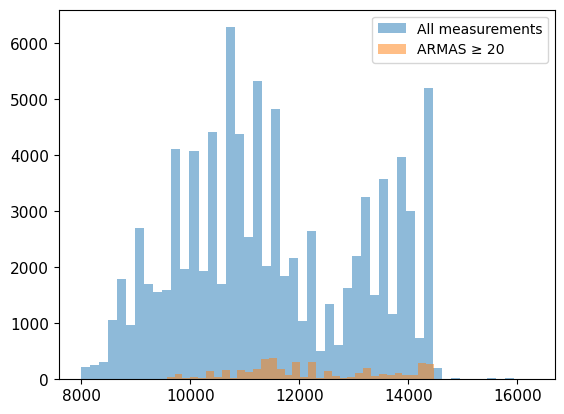

In [43]:
plt.hist(
    df_all["Altitude(GPS)"],
    bins=50,
    alpha=0.5,
    label="All measurements"
)

plt.hist(
    extreme_df["Altitude(GPS)"],
    bins=50,
    alpha=0.5,
    label="ARMAS ≥ 20"
)

plt.legend()
plt.show()

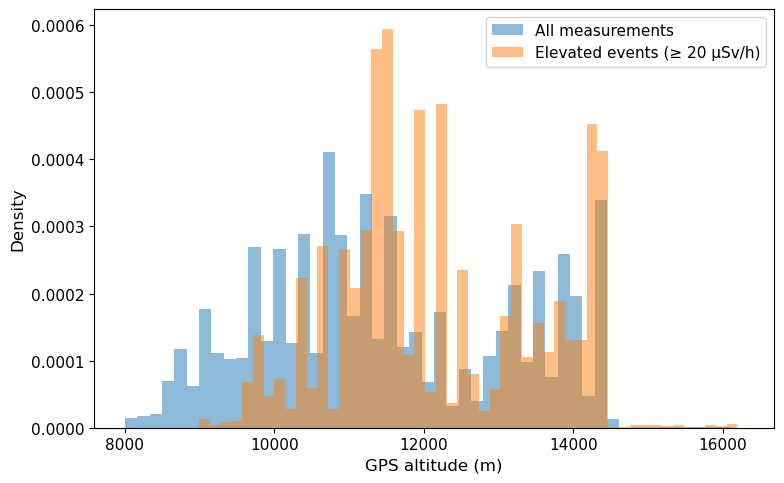

In [44]:
# figure for thesis

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_all["Altitude(GPS)"], bins=50, alpha=0.5,
        density=True, label="All measurements")
ax.hist(extreme_df["Altitude(GPS)"], bins=50, alpha=0.5,
        density=True, label="Elevated events (≥ 20 µSv/h)")

ax.set_xlabel("GPS altitude (m)")
ax.set_ylabel("Density")
ax.legend()

fig.tight_layout()
fig.savefig("fig_elevated_altitude.pdf", bbox_inches="tight")
plt.show()

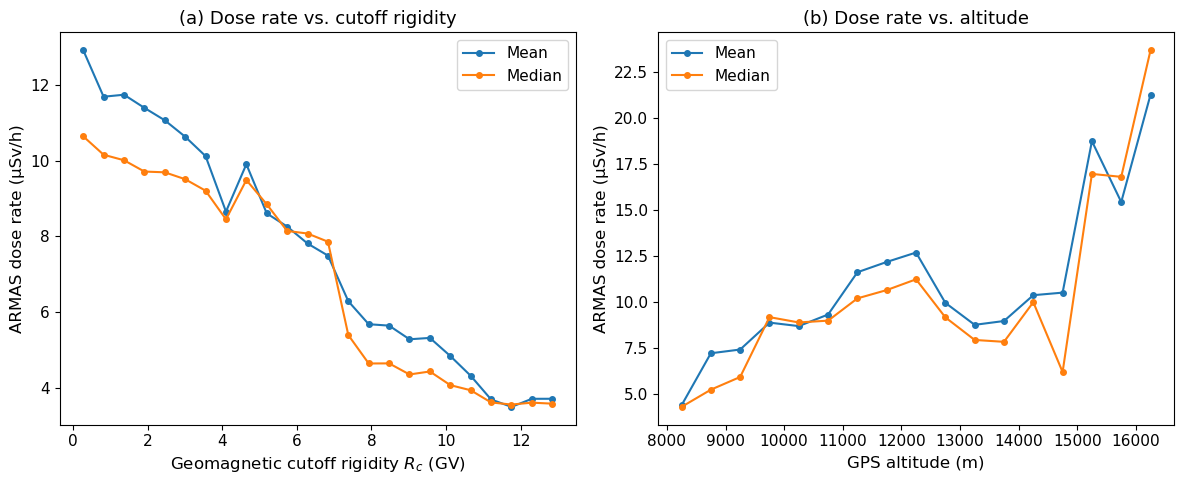

In [45]:
# thesis figure 

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
})

alt_col = "Altitude(GPS)"
geo_rc  = "Geomagnetic_Rc"

# --- Rc-Bins ---
df_all["rc_bin"] = pd.cut(
    df_all[geo_rc],
    bins=np.linspace(df_all[geo_rc].min(), df_all[geo_rc].max(), 25)
)
rc_summary = (
    df_all.groupby("rc_bin", observed=True)
    .agg(mean_ARMAS=("ARMAS", "mean"), median_ARMAS=("ARMAS", "median"))
    .reset_index()
)
rc_summary["rc_mid"] = rc_summary["rc_bin"].apply(lambda x: x.mid)

# --- Höhen-Bins ---
df_all["altitude_bin"] = pd.cut(
    df_all[alt_col],
    bins=np.arange(df_all[alt_col].min(), df_all[alt_col].max() + 500, 500)
)
alt_summary = (
    df_all.groupby("altitude_bin", observed=True)
    .agg(mean_ARMAS=("ARMAS", "mean"), median_ARMAS=("ARMAS", "median"))
    .reset_index()
)
alt_summary["altitude_mid"] = alt_summary["altitude_bin"].apply(lambda x: x.mid)

# --- 2-Panel ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(rc_summary["rc_mid"], rc_summary["mean_ARMAS"],
             marker="o", markersize=4, label="Mean")
axes[0].plot(rc_summary["rc_mid"], rc_summary["median_ARMAS"],
             marker="o", markersize=4, label="Median")
axes[0].set_xlabel("Geomagnetic cutoff rigidity $R_c$ (GV)")
axes[0].set_ylabel("ARMAS dose rate (µSv/h)")
axes[0].set_title("(a) Dose rate vs. cutoff rigidity")
axes[0].legend()

axes[1].plot(alt_summary["altitude_mid"], alt_summary["mean_ARMAS"],
             marker="o", markersize=4, label="Mean")
axes[1].plot(alt_summary["altitude_mid"], alt_summary["median_ARMAS"],
             marker="o", markersize=4, label="Median")
axes[1].set_xlabel("GPS altitude (m)")
axes[1].set_ylabel("ARMAS dose rate (µSv/h)")
axes[1].set_title("(b) Dose rate vs. altitude")
axes[1].legend()

fig.tight_layout()
fig.savefig("fig_armas_drivers.pdf", bbox_inches="tight")
plt.show()

Notes:
Extreme radiation events are concentrated at higher flight altitudes compared to the overall measurement distribution.

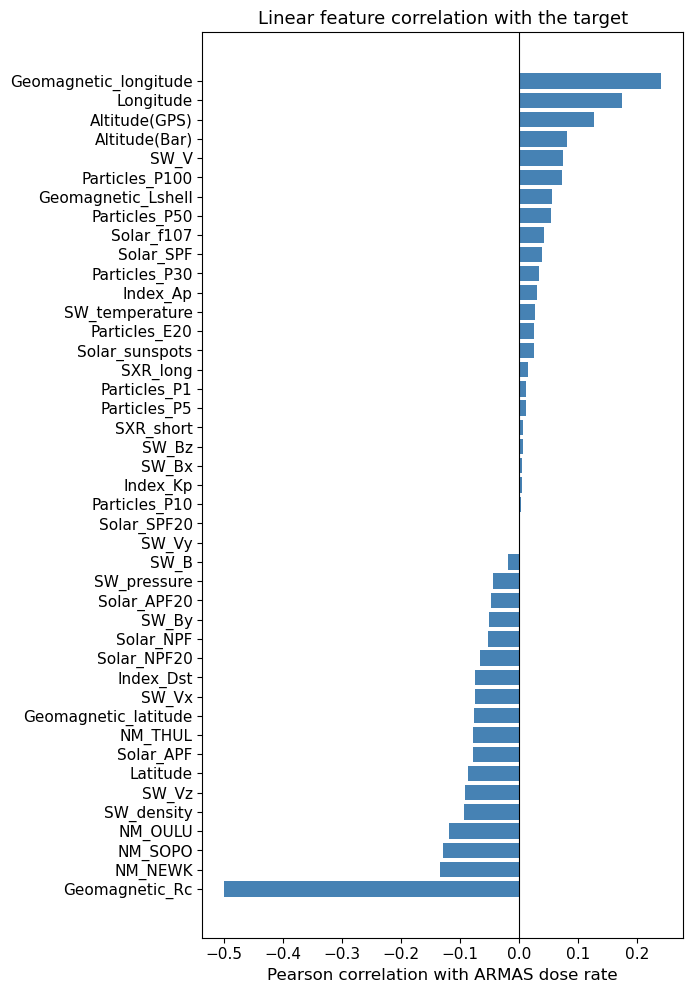

In [48]:
# thesis figure
import matplotlib.pyplot as plt

drop_for_plot = [
    "ARMAS", "residual_v2", "residual_v3", "NAIRASV2", "NAIRASV3",
    "flight_id", "Vehicle_ID", "Datetime", "time_gap",
    "altitude_bin", "rc_bin", "Partition",
]

# nur numerische Spalten, dann erst die unerwünschten droppen
numeric = df_all.select_dtypes(include="number")
numeric = numeric.drop(columns=[c for c in drop_for_plot if c in numeric.columns])

corr = numeric.corrwith(df_all["ARMAS"]).sort_values()

plt.rcParams.update({"font.size": 9})
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(corr.index, corr.values, color="steelblue")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with ARMAS dose rate")
ax.set_title("Linear feature correlation with the target")
fig.tight_layout()
fig.savefig("fig_feature_correlation.pdf", bbox_inches="tight")
plt.show()